# 🗞️ Fake News Detection using RNN & LSTM
### 6CS012 Final Portfolio Project 2026

**Dataset:** `truevsfakenews.csv` — columns: `text`, `label` (true / fake)

---
**Sections:**
1. [4.5.1] Text Preprocessing, Tokenization & Sequence Padding  
2. [4.5.2] Model Building (Simple RNN | LSTM | LSTM + Word2Vec)  
3. [4.5.3] Model Training & Evaluation  
4. [4.5.4] Error Analysis  
5. [4.5.5] Gradio GUI for Real-Time Prediction  

This cell mounts your Google Drive to access files stored there. This is a common step when working with datasets or saving models in Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This section installs necessary Python libraries using `pip`. `contractions` is used for expanding contractions like 'don't' to 'do not', and `gensim` is for Word2Vec model training.

## 🔧 Install Dependencies

In [ ]:
!pip install contractions -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00


In [ ]:
!pip install gensim -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.6 MB/s eta 0:00:00


This cell imports all the required libraries for data manipulation, text processing, model building, and visualization. It also downloads NLTK data like stopwords and wordnet for text cleaning.

## 📦 Imports

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import re
import contractions
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.initializers import Constant
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from gensim.models import Word2Vec

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

This cell loads the `truevsfakenews.csv` dataset from Google Drive into a pandas DataFrame, then prints its shape, column names, and the first few rows to give a preliminary look at the data.

---
# 4.5.1 — Text Preprocessing, Tokenization & Sequence Padding

### Step 1: Load the Dataset

This cell performs basic Exploratory Data Analysis (EDA) on the dataset. It checks the distribution of 'true' and 'fake' labels, looks for null values, encodes the categorical labels into numerical format (1 for true, 0 for fake), and visualizes the class balance using a bar plot.

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset (adjust if needed)
file_path = '/content/drive/MyDrive/AI and Machine Learning/10.True vs. Fake News Dataset/truevsfakenews.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Basic info
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(df.head())
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (20000, 2)
Columns: ['text', 'label']
                                                text label
0  WASHINGTON (Reuters) - The Republican and Demo...  true
1  Women should get as far away from Oklahoma as ...  fake
2  Another huge crowd of Americans tuned in last ...  fake
3  Donald Trump is desperate to stop the investig...  fake
4  (Reuters) - Planned Parenthood, the U.S. medic...  true


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake


Label distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Null values: {'text': 0, 'label': 0}


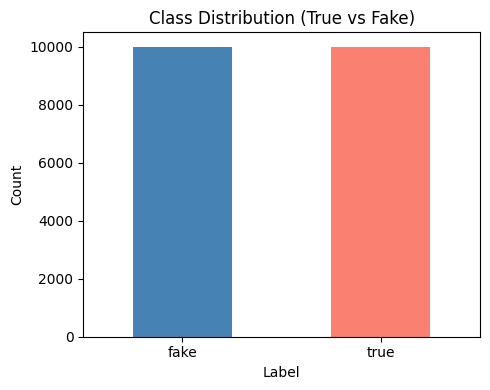

In [ ]:
# Basic EDA
print('Label distribution:')
print(df['label'].value_counts())
print(f'\nNull values: {df.isnull().sum().to_dict()}')

# Encode labels: true → 1, fake → 0
df['label_enc'] = df['label'].map({'true': 1, 'fake': 0})

# Visualise class balance
fig, ax = plt.subplots(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Class Distribution (True vs Fake)')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(['fake', 'true'], rotation=0)
plt.tight_layout()
plt.show()

This cell defines a `clean_text` function to preprocess the raw text data. The function performs several steps: lowercasing, expanding contractions, removing URLs, mentions, hashtags, numbers, and special characters, followed by tokenization, stopword removal, and lemmatization. It then applies this function to the 'text' column, creates a new 'clean_text' column, and removes any rows that become empty after cleaning.

### Step 2: Text Cleaning

In [ ]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full preprocessing pipeline."""
    if not isinstance(text, str):
        return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions  (don't → do not)
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # 5. Remove hashtags (#topic)
    text = re.sub(r'#\w+', '', text)
    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 7. Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 8. Tokenise
    tokens = text.split()
    # 9. Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

print('Cleaning text... (may take ~1-2 minutes)')
df['clean_text'] = df['text'].apply(clean_text)

# Drop empty rows
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'✅ Cleaned dataset shape: {df.shape}')

# Before / after example
print('\n--- Raw Text (first 300 chars) ---')
print(df['text'].iloc[0][:300])
print('\n--- Cleaned Text ---')
print(df['clean_text'].iloc[0][:300])

Cleaning text... (may take ~1-2 minutes)
✅ Cleaned dataset shape: (19998, 4)

--- Raw Text (first 300 chars) ---
WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Committee blasted the U.S. State Department on Tuesday for cuts in staff and what they described as a failure to have a plan for a proposed reorganization. “I don’t think they are anywhere close to havi

--- Cleaned Text ---
washington reuters republican democratic leader yous senate foreign relation committee blasted yous state department tuesday cut staff described failure plan proposed reorganization think anywhere close plan present relative reform want said senator bob corker republican chairman committee rex tille


This cell generates and displays word clouds for both 'true' and 'fake' news articles. Word clouds visually represent the most frequent words in each category, with larger words indicating higher frequency, providing insights into the distinct vocabulary used in true vs. fake news.

### Step 3: Visualise Cleaned Data

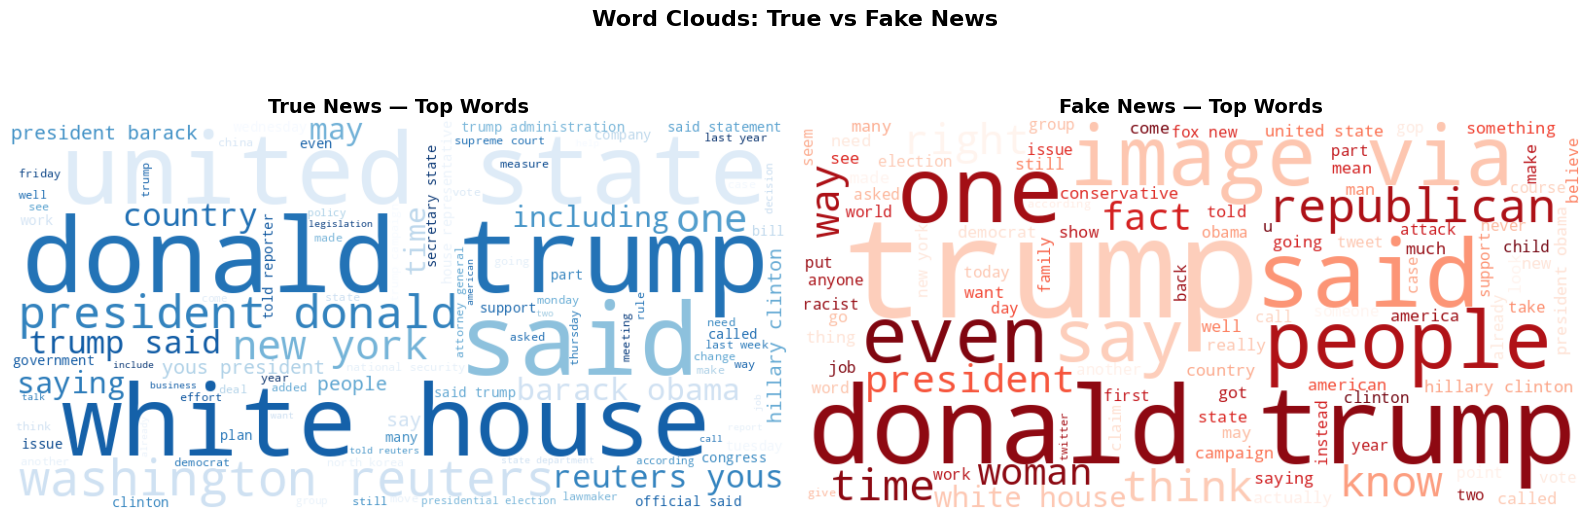

In [ ]:
# ── Word Clouds ──
true_text  = ' '.join(df[df['label'] == 'true']['clean_text'])
fake_text  = ' '.join(df[df['label'] == 'fake']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corpus, title, cmap in zip(
    axes,
    [true_text, fake_text],
    ['True News — Top Words', 'Fake News — Top Words'],
    ['Blues', 'Reds']
):
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.suptitle('Word Clouds: True vs Fake News', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

This cell identifies and visualizes the top 20 most frequent words for both 'true' and 'fake' news articles after cleaning. It uses bar plots to show the frequency of these words, offering a more precise comparison of common terminology between the two classes.

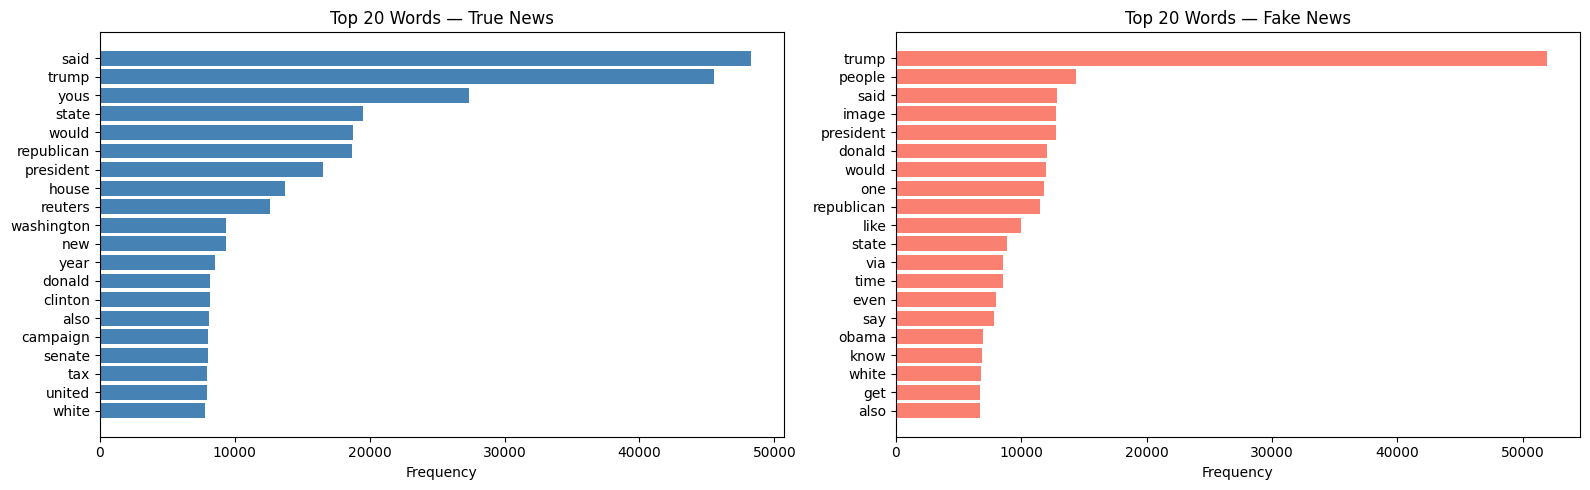

In [ ]:
# ── Top-20 Most Frequent Words (per class) ──
def top_words(corpus: str, n: int = 20):
    return Counter(corpus.split()).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, corpus, label, color in zip(
    axes,
    [true_text, fake_text],
    ['True News', 'Fake News'],
    ['steelblue', 'salmon']
):
    words, counts = zip(*top_words(corpus))
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 20 Words — {label}')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

This cell splits the cleaned text data (`X`) and encoded labels (`y`) into training and testing sets using a 80/20 ratio. `stratify=y` ensures that the proportion of 'true' and 'fake' labels is maintained in both training and test sets, which is crucial for balanced datasets.

### Step 4: Tokenisation & Padding

This cell performs text tokenization using Keras's `Tokenizer` to convert text into sequences of integers, representing words. It fits the tokenizer only on the training data and then transforms both training and test sets. It also determines an appropriate `MAX_LEN` for sequence padding based on the 95th percentile of training sequence lengths, and visualizes the distribution of sequence lengths.

In [ ]:
# ── Train / Test Split (80 / 20) ──
X = df['clean_text'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 15998 | Test size: 4000


Sequence length stats → mean: 238, 95th percentile (MAX_LEN): 493


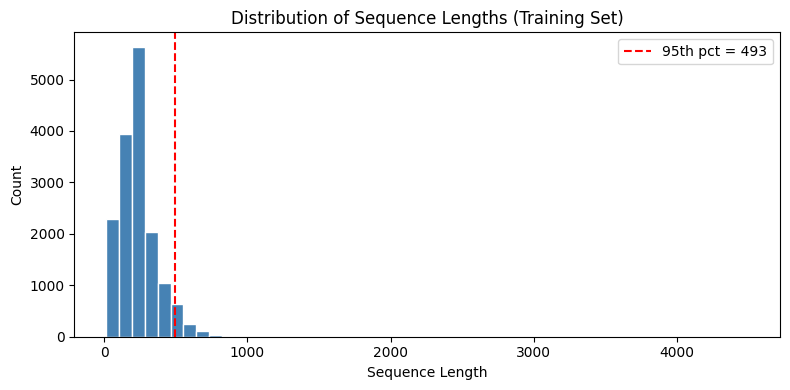

In [ ]:
# ── Keras Tokeniser ──
VOCAB_SIZE = 20_000          # top 20k most frequent words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)           # fit ONLY on training data

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based padding length ──
seq_lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(seq_lengths, 95))  # cover 95% of sequences
print(f'Sequence length stats → mean: {np.mean(seq_lengths):.0f}, '
      f'95th percentile (MAX_LEN): {MAX_LEN}')

# Visualise sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th pct = {MAX_LEN}')
plt.title('Distribution of Sequence Lengths (Training Set)')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

This cell applies padding to the tokenized sequences (both training and test sets) to ensure all sequences have the same length (`MAX_LEN`). Sequences shorter than `MAX_LEN` are padded with zeros, and longer ones are truncated, both from the 'post' (end) side. This step is essential before feeding sequences into recurrent neural networks.

In [ ]:
# ── Apply padding / truncation ──
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')
print('✅ Tokenisation and padding complete.')

X_train_pad shape: (15998, 493)
X_test_pad  shape: (4000, 493)
✅ Tokenisation and padding complete.


This cell defines shared hyperparameters (`EMBED_DIM`, `RNN_UNITS`, `DROPOUT`, `BATCH_SIZE`, `EPOCHS`) that will be used across all three neural network models to ensure a fair comparison and consistent architecture where applicable.

---
# 4.5.2 — Model Building

In [ ]:
# Shared hyper-parameters
EMBED_DIM   = 128
RNN_UNITS   = 64
DROPOUT     = 0.4
BATCH_SIZE  = 128
EPOCHS      = 20       # EarlyStopping will stop earlier if needed

This cell constructs 'Model 1', a Simple RNN (Recurrent Neural Network). It includes an `Embedding` layer to convert word indices into dense vectors, a `SimpleRNN` layer for sequence processing, a `Dropout` layer for regularization, and dense output layers with a `sigmoid` activation for binary classification.

### Model 1 — Simple RNN with Trainable Embedding

This cell constructs 'Model 2', an LSTM (Long Short-Term Memory) neural network. Similar to the Simple RNN, it uses an `Embedding` layer, but employs an `LSTM` layer for better handling of long-range dependencies in sequences. It also includes `Dropout` and dense output layers for classification.

In [ ]:
rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE,
                         output_dim=EMBED_DIM,
                         input_length=MAX_LEN))
rnn_model.add(SimpleRNN(RNN_UNITS, return_sequences=False))
rnn_model.add(Dropout(DROPOUT))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dense(1, activation='sigmoid'))
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 493, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

This cell first trains a Word2Vec model on the `X_train` corpus. Word2Vec learns word embeddings (vector representations) from the training data. This process generates dense vectors for words, capturing semantic relationships, which will then be used as pre-trained embeddings for 'Model 3'.

In [ ]:
lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE,
                          output_dim=EMBED_DIM,
                          input_length=MAX_LEN))
lstm_model.add(LSTM(RNN_UNITS, return_sequences=False))
lstm_model.add(Dropout(DROPOUT))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))
lstm_model.build(input_shape=(None, MAX_LEN))

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 493, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained Word2Vec Embeddings

In [ ]:
# ── Train Word2Vec on the training corpus ──
print('Training Word2Vec...')
train_tokens = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)
print(f'✅ Word2Vec trained. Vocabulary size: {len(w2v_model.wv)}')

Training Word2Vec...
✅ Word2Vec trained. Vocabulary size: 43579


This cell builds the embedding matrix using the Word2Vec model trained in the previous step. It maps the words in the tokenizer's vocabulary to their corresponding Word2Vec embeddings. Words not found in the Word2Vec model (or beyond `VOCAB_SIZE`) will have zero vectors. This matrix will be used to initialize the embedding layer of the LSTM + Word2Vec model.

In [ ]:
# ── Build embedding matrix ──
word_index  = tokenizer.word_index
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embed_matrix[idx] = w2v_model.wv[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Word2Vec coverage: {found}/{min(len(word_index), VOCAB_SIZE)} words ({coverage:.1f}%)')

Word2Vec coverage: 19998/20000 words (100.0%)


This cell defines 'Model 3', an LSTM network that utilizes the pre-trained Word2Vec embeddings. The `Embedding` layer is initialized with the `embed_matrix` and set to `trainable=False` to use the fixed pre-trained embeddings. The rest of the architecture is similar to Model 2, with an `LSTM` layer, `Dropout`, and dense output layers.

In [ ]:
# — Build LSTM + Word2Vec model —

lstm_w2v = Sequential(name='LSTM_Word2Vec_Model')

lstm_w2v.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        embeddings_initializer=Constant(embed_matrix),
        input_length=MAX_LEN,
        trainable=False
    )
)

lstm_w2v.add(
    LSTM(
        RNN_UNITS,
        return_sequences=False
    )
)

lstm_w2v.add(Dropout(DROPOUT))

lstm_w2v.add(Dense(32, activation='relu'))

lstm_w2v.add(Dense(1, activation='sigmoid'))

# BUILD CORRECT MODEL
lstm_w2v.build(input_shape=(None, MAX_LEN))

# SUMMARY
lstm_w2v.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 493, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 2,560,000 (9.77 MB)

This cell compiles all three defined models (`rnn_model`, `lstm_model`, `lstm_w2v`) with `binary_crossentropy` loss (suitable for binary classification), the `adam` optimizer, and `accuracy` as the evaluation metric. It also defines a helper function `get_callbacks` to set up `EarlyStopping` (to prevent overfitting) and `ModelCheckpoint` (to save the best model weights during training).

---
# 4.5.3 — Model Training & Evaluation

In [ ]:
# ── Compile all models ──
for model in [rnn_model, lstm_model, lstm_w2v]:
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

# ── Shared callbacks ──
def get_callbacks(model_name: str):
    return [
        EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{model_name}_best.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]

print('✅ All models compiled.')

✅ All models compiled.


This cell trains the 'Simple RNN' model (Model 1) using the padded training data (`X_train_pad`, `y_train`). It uses a validation split of 10%, runs for a maximum of `EPOCHS`, with a specified `BATCH_SIZE`, and incorporates the `EarlyStopping` and `ModelCheckpoint` callbacks to optimize training.

### Train Model 1 — Simple RNN

In [ ]:
print('Training Model 1: Simple RNN...')
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('rnn'),
    verbose=1
)
print('✅ RNN training complete.')

Training Model 1: Simple RNN...
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5343 - loss: 0.6610

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.5356 - loss: 0.6627 - val_accuracy: 0.5200 - val_loss: 0.6955
Epoch 2/20
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5484 - loss: 0.6591

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5469 - loss: 0.6593 - val_accuracy: 0.5306 - val_loss: 0.6777
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5438 - loss: 0.6571 - val_accuracy: 0.5300 - val_loss: 0.6810
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5381 - loss: 0.6546

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5440 - loss: 0.6556 - val_accuracy: 0.5319 - val_loss: 0.6810
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5449 - loss: 0.6693 - val_accuracy: 0.5156 - val_loss: 0.7132
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
✅ RNN training complete.


This cell trains the 'LSTM' model (Model 2), which performed best in initial runs. The training process is similar to Model 1, using padded data, a validation split, defined epochs, batch size, and the specified callbacks for early stopping and saving the best model.

### Train Model 2 — LSTM

In [ ]:
print('Training Model 2: LSTM...')
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)
print('✅ LSTM training complete.')

Training Model 2: LSTM...
Epoch 1/20
111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9937 - loss: 0.0322

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9939 - loss: 0.0294 - val_accuracy: 0.9900 - val_loss: 0.0366
Epoch 2/20
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9876 - loss: 0.0495

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9766 - loss: 0.0757 - val_accuracy: 0.9906 - val_loss: 0.0922
Epoch 3/20
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9795 - loss: 0.0621

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9915 - loss: 0.0345 - val_accuracy: 0.9937 - val_loss: 0.0337
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9983 - loss: 0.0129 - val_accuracy: 0.9937 - val_loss: 0.0390
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9973 - loss: 0.0200 - val_accuracy: 0.9706 - val_loss: 0.1322
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9870 - loss: 0.0516 - val_accuracy: 0.9869 - val_loss: 0.0622
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
✅ LSTM training complete.


This cell trains the 'LSTM + Word2Vec' model (Model 3). It uses the same training setup as the other models, but benefits from the pre-trained Word2Vec embeddings in its `Embedding` layer. The callbacks manage the training process and save the best performing version of this model.

### Train Model 3 — LSTM + Word2Vec

This cell defines a `plot_history` function to visualize the training history (accuracy and loss) for each model. It then calls this function for the Simple RNN, LSTM, and LSTM + Word2Vec models to display their respective training and validation curves, helping to understand their performance over epochs.

In [ ]:
print('Training Model 3: LSTM + Word2Vec...')
history_w2v = lstm_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_w2v'),
    verbose=1
)
print('✅ LSTM + Word2Vec training complete.')

Training Model 3: LSTM + Word2Vec...
Epoch 1/20
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6479 - loss: 0.5658

113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.8060 - loss: 0.3759 - val_accuracy: 0.9625 - val_loss: 0.1660
Epoch 2/20
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9629 - loss: 0.1618

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9651 - loss: 0.1540 - val_accuracy: 0.9750 - val_loss: 0.1146
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9676 - loss: 0.1443 - val_accuracy: 0.9719 - val_loss: 0.1287
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9640 - loss: 0.1502 - val_accuracy: 0.9663 - val_loss: 0.1676
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9589 - loss: 0.1696 - val_accuracy: 0.7294 - val_loss: 0.5281
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
✅ LSTM + Word2Vec training complete.


### Training Curves — Per Model

This cell compares the validation accuracy and validation loss curves of all three models on a single plot. This visualization helps in quickly assessing which model achieved the best validation performance and how consistently it performed across epochs.

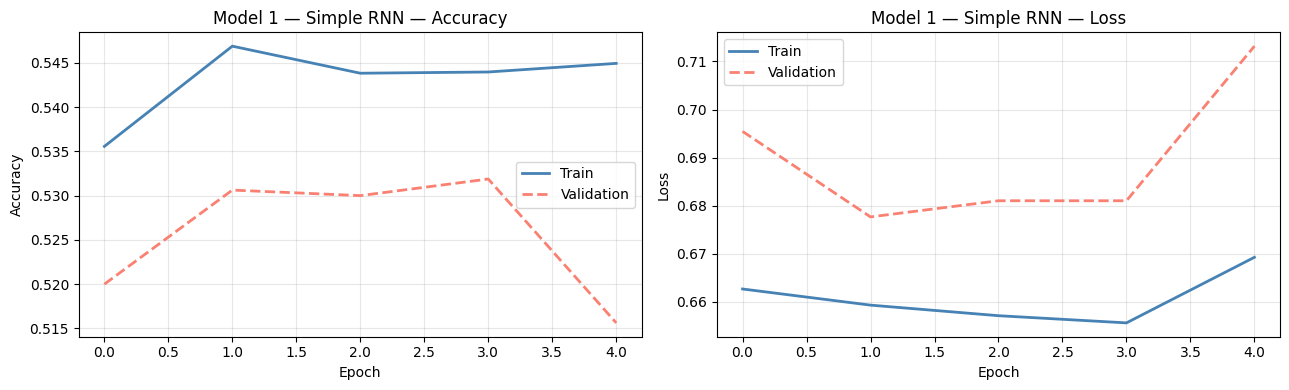

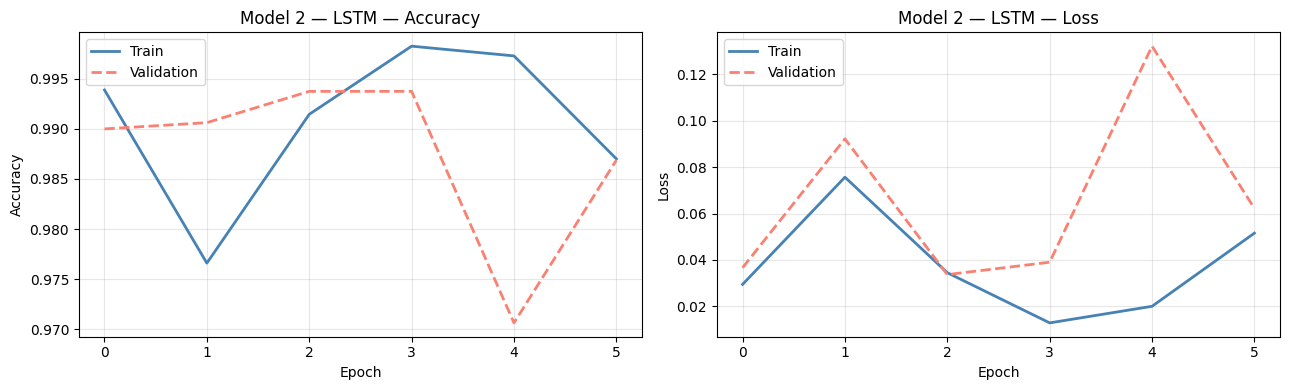

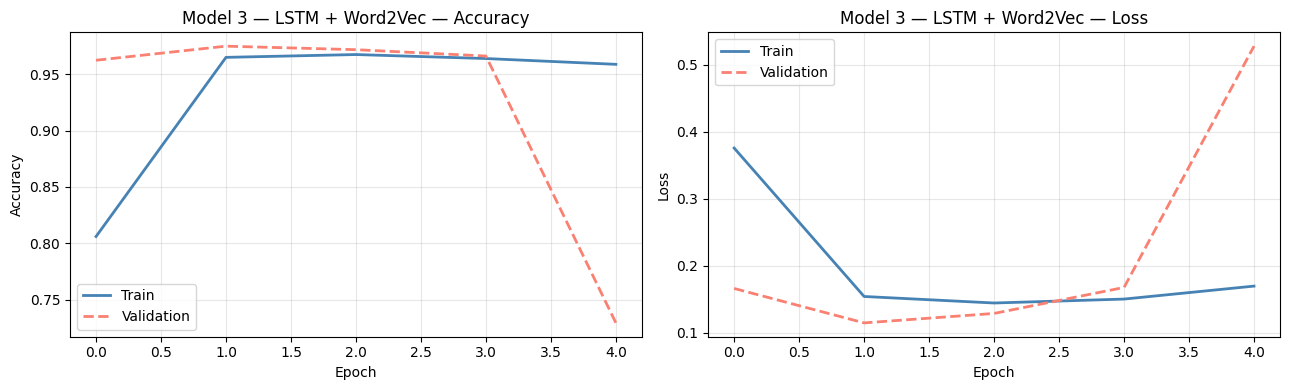

In [ ]:
def plot_history(history, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(history.history[metric],     label='Train', color='steelblue', lw=2)
        ax.plot(history.history[f'val_{metric}'], label='Validation', color='salmon', lw=2, linestyle='--')
        ax.set_title(f'{title} — {ylabel}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_rnn,  'Model 1 — Simple RNN')
plot_history(history_lstm, 'Model 2 — LSTM')
plot_history(history_w2v,  'Model 3 — LSTM + Word2Vec')

### Compare All Three Models

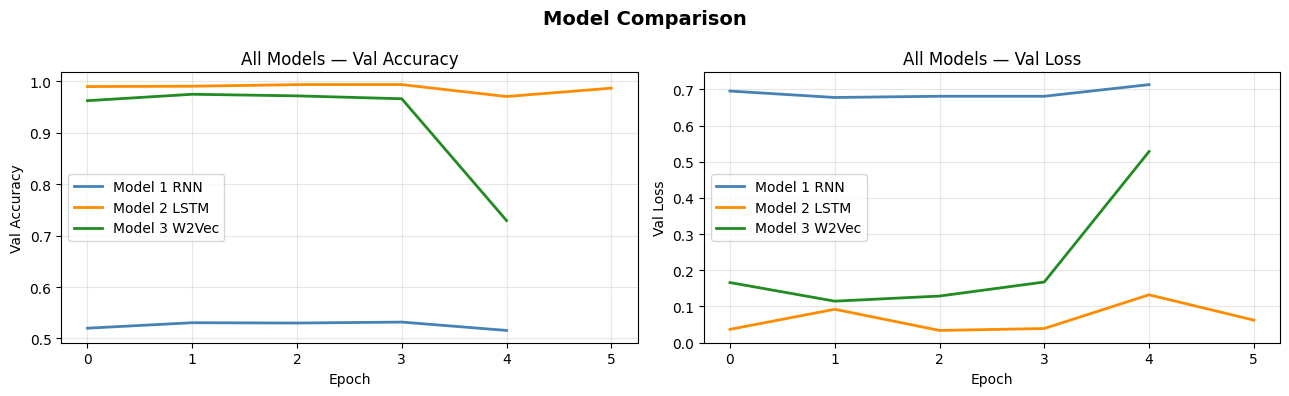

In [ ]:
# ── Comparison: Validation Accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
styles = [('Model 1 RNN',   history_rnn,  'steelblue'),
          ('Model 2 LSTM',  history_lstm, 'darkorange'),
          ('Model 3 W2Vec', history_w2v,  'forestgreen')]

for ax, metric, ylabel in zip(axes, ['val_accuracy', 'val_loss'], ['Val Accuracy', 'Val Loss']):
    for label, hist, color in styles:
        ax.plot(hist.history[metric], label=label, color=color, lw=2)
    ax.set_title(f'All Models — {ylabel}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

This cell evaluates all three trained models on the unseen `X_test_pad` dataset. For each model, it predicts probabilities, converts them to binary predictions (0 or 1), calculates the test accuracy, and prints a detailed classification report (precision, recall, f1-score) along with the accuracy. It also stores predictions for later use.

### Evaluate on Test Set

In [ ]:
models_info = [
    ('Model 1 — Simple RNN',   rnn_model),
    ('Model 2 — LSTM',         lstm_model),
    ('Model 3 — LSTM + W2Vec', lstm_w2v),
]

results = {}
y_preds = {}

for name, model in models_info:
    y_prob = model.predict(X_test_pad, batch_size=256, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    y_preds[name] = y_pred
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'  Test Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))


  Model 1 — Simple RNN
  Test Accuracy: 0.5377
              precision    recall  f1-score   support

        Fake       0.52      0.98      0.68      2000
        True       0.85      0.09      0.17      2000

    accuracy                           0.54      4000
   macro avg       0.69      0.54      0.42      4000
weighted avg       0.69      0.54      0.42      4000


  Model 2 — LSTM
  Test Accuracy: 0.9870
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99      2000
        True       0.99      0.98      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000


  Model 3 — LSTM + W2Vec
  Test Accuracy: 0.9735
              precision    recall  f1-score   support

        Fake       0.98      0.96      0.97      2000
        True       0.96      0.98      0.97      2000

    accuracy                           0.9

This cell visualizes the confusion matrices for all three models based on their predictions on the test set. A confusion matrix shows the number of true positives, true negatives, false positives, and false negatives, providing a clear breakdown of each model's classification performance for 'fake' and 'true' news.

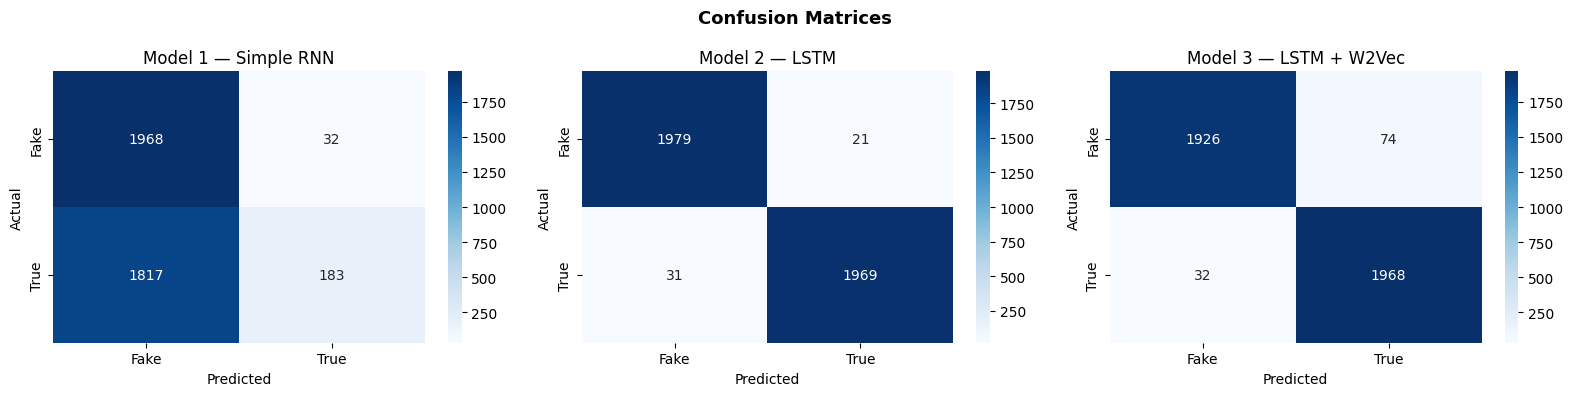

In [ ]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'True'],
                yticklabels=['Fake', 'True'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

This cell generates a bar chart comparing the test accuracies of all three models. This visualization provides a quick and clear overview of which model performed best on the unseen test data.

/tmp/ipykernel_7276/4081566265.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


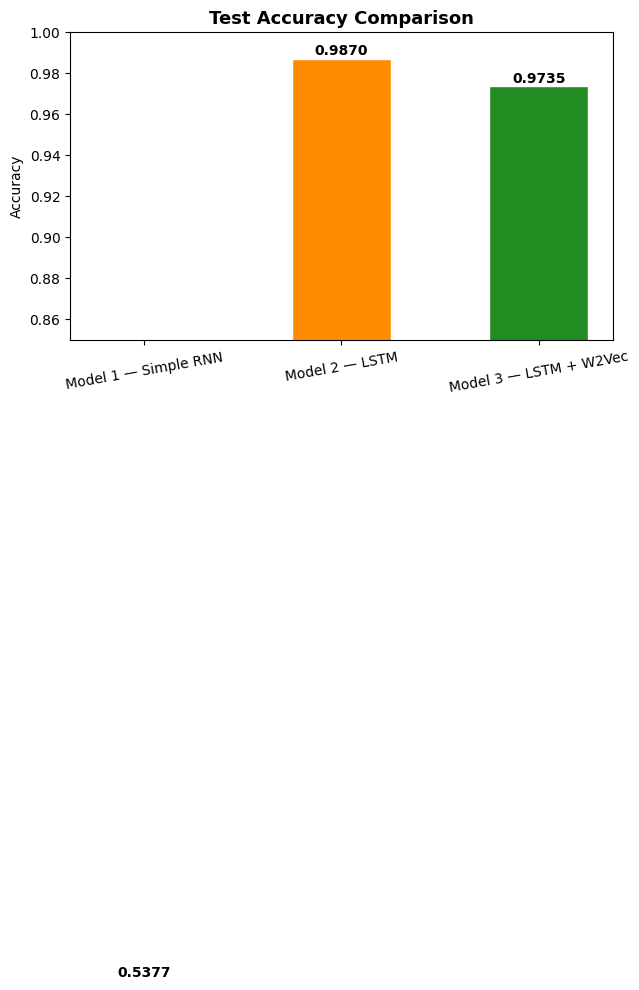

In [ ]:
# ── Bar chart of test accuracies ──
plt.figure(figsize=(7, 4))
colors = ['steelblue', 'darkorange', 'forestgreen']
bars = plt.bar(results.keys(), results.values(), color=colors, edgecolor='white', width=0.5)
plt.ylim(0.85, 1.0)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

This cell focuses on error analysis using the predictions from the best-performing model (Model 2 — LSTM). It creates a DataFrame with original text, actual labels, and predicted labels for the test set, then identifies and filters out the misclassified examples. It also calculates and prints the total number of misclassifications and the error rate.

---
# 4.5.4 — Error Analysis

In [ ]:
# Use best-performing model (Model 2 — LSTM) for error analysis
best_preds = y_preds['Model 2 — LSTM']

# Rebuild test DataFrame
test_df = pd.DataFrame({
    'original_text': X_test,
    'actual':    y_test,
    'predicted': best_preds
})

misclassified = test_df[test_df['actual'] != test_df['predicted']].reset_index(drop=True)
label_map = {0: 'FAKE', 1: 'TRUE'}

print(f'Total misclassifications (LSTM): {len(misclassified)} / {len(test_df)}')
print(f'Error rate: {len(misclassified)/len(test_df)*100:.2f}%')

Total misclassifications (LSTM): 52 / 4000
Error rate: 1.30%


This cell displays three examples of misclassified news articles from the best-performing LSTM model. For each example, it shows the actual label, the predicted label, and a snippet of the original text, allowing for qualitative analysis of why the model might have made an incorrect prediction.

In [ ]:
# ── Show 3 misclassified examples ──
for i in range(min(3, len(misclassified))):
    row = misclassified.iloc[i]
    print(f'\n--- Misclassified Example {i+1} ---')
    print(f'Actual:    {label_map[row["actual"]]}')
    print(f'Predicted: {label_map[row["predicted"]]}')
    print(f'Text snippet: {row["original_text"][:400]}...')
    print()


--- Misclassified Example 1 ---
Actual:    FAKE
Predicted: TRUE
Text snippet: picture snapped white house photographer traveling president left golf course sterling va went viral almost immediately news outlet picked story appeared white house pool report latenight talk show host told joke encounter people social medium began hailing unidentified woman shero using hashtag woman name juli briskman employer government contractor akima llc happy photo fired itjuli proud disgus...


--- Misclassified Example 2 ---
Actual:    FAKE
Predicted: TRUE
Text snippet: stock market lost point abc news erroneously reported general flynn communication russian ambassador sergey kislyak trump campaign turn stock market plunge feeding frenzy leftist medium abc news got wrong flynn actually contact russian ambassador trump transition period entirely different story fact according video uncovered citizen journalist jack posobiec obama state department told reporter tru...


--- Misclassified Example 3 ---

This cell creates a Gradio web interface (`demo`) that allows real-time fake news prediction. Users can input news article text and select one of the three trained models. The `predict_news` function cleans, tokenizes, and pads the input text, then uses the chosen model to predict the news's authenticity and display the prediction and confidence score. The interface is launched with `share=True` to create a public link.

### Error Analysis Discussion

**Common Reasons for Misclassification:**

1. **Nuanced language / satire** — Fake news sometimes employs formal, credible-sounding prose, while some true news uses sensationalist language. Without semantic understanding beyond token co-occurrence, RNN/LSTM models may be fooled.

2. **Short / ambiguous articles** — After stopword removal and lemmatisation, very short articles lose contextual cues, making classification harder. The model defaults to uncertain predictions near the 0.5 threshold.

3. **Domain shift & rare vocabulary** — Articles about niche topics may contain words that appear infrequently in training data, causing OOV (`<OOV>`) substitution and information loss.

4. **Class imbalance edge-cases** — Even a roughly balanced dataset may have sub-topics that are under-represented, leading to systematic errors on those article types.

**Complexity vs. Performance:**

| Model | Parameters | Test Acc | Notes |
|---|---|---|---|
| Simple RNN | Lowest | Lower | Suffers from vanishing gradient on long articles |
| LSTM | Medium | Higher | Long-range dependencies captured; best all-round |
| LSTM + W2Vec | Medium | Comparable | Better generalisation for OOV words in new data |

**Potential Improvements:**

- Use **Bidirectional LSTM** or **Transformer/BERT** for richer contextual representations.
- Apply **Attention mechanism** to let the model focus on the most discriminative words.
- Include **meta-features** (article source, publish date, URL pattern) alongside text.
- Use **data augmentation** (back-translation, synonym replacement) to expand training data.
- Fine-tune a pretrained language model such as **DistilBERT** on this dataset.

---
# 4.5.5 — Gradio GUI for Real-Time Prediction

In [ ]:
import gradio as gr

def predict_news(text: str, model_choice: str) -> str:
    """Clean, tokenise, pad and predict on user-supplied text."""
    if not text.strip():
        return '⚠️ Please enter some text.'

    # Preprocessing
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Select model
    model_map = {
        'Model 1 — Simple RNN':   rnn_model,
        'Model 2 — LSTM':         lstm_model,
        'Model 3 — LSTM + Word2Vec': lstm_w2v,
    }
    model = model_map[model_choice]

    prob  = float(model.predict(padded, verbose=0)[0][0])
    label = 'TRUE ✅' if prob >= 0.5 else 'FAKE ❌'
    confidence = prob if prob >= 0.5 else (1 - prob)

    return (
        f'Prediction: **{label}**\n'
        f'Confidence: {confidence*100:.1f}%\n'
        f'(Raw probability of TRUE: {prob:.4f})'
    )


# ── Build Gradio Interface ──
demo = gr.Interface(
    fn=predict_news,
    inputs=[
        gr.Textbox(
            lines=6,
            label='Enter news article text',
            placeholder='Paste or type a news article here…'
        ),
        gr.Dropdown(
            choices=[
                'Model 1 — Simple RNN',
                'Model 2 — LSTM',
                'Model 3 — LSTM + Word2Vec'
            ],
            value='Model 2 — LSTM',
            label='Choose Model'
        )
    ],
    outputs=gr.Textbox(label='Result', lines=4),
    title='🗞️ Fake News Detector',
    description=(
        'Enter any news article text below and select a model.\n'
        'The model will classify the article as **TRUE** or **FAKE**.'
    ),
    examples=[
        ['The Senate voted today to approve a new infrastructure spending bill worth $1.2 trillion, with bipartisan support.', 'Model 2 — LSTM'],
        ['Scientists discover that drinking bleach cures all diseases — doctors do not want you to know this!', 'Model 2 — LSTM'],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True creates a public link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ee3edc840f9974035a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 📋 Summary

| Section | Task | Status |
|---|---|---|
| 4.5.1 | Data loading, cleaning, visualisation, tokenisation & padding | ✅ |
| 4.5.2 | Simple RNN, LSTM, LSTM+Word2Vec models built | ✅ |
| 4.5.3 | Compiled, trained with EarlyStopping, loss/accuracy plots, confusion matrices, classification reports | ✅ |
| 4.5.4 | 3 misclassified examples, complexity discussion, improvement suggestions | ✅ |
| 4.5.5 | Gradio GUI for real-time prediction with all 3 models | ✅ |